# Phase 4 results — the seven-method comparison on `bench_phase4`

Every figure in this notebook is a `groupby` over **one file**,
`out/phase4_batch/phase4_batch.csv.gz` (173 000 rows), produced by
`scripts/run_phase4_batch.py` over the corpus `out/bench_phase4` (720 scenes, 60 per
family) and its fixture twins `out/bench_phase4_fx`. **No cell here runs a method.** If a
number needs recomputing, delete the chunk file and re-run the batch script; if a stratum
is rebuilt, `--retire` + `--append-missing` repair the dataframe in place.

**What is being measured.** Each method receives a point cloud and returns weld-seam
polylines; they are scored against *constructed* truth — the seam is computed in closed
form from the placement transforms, so there is no annotator anywhere in the label path
(the Phase 5 study measured what an annotator adds: a 1,4 mm median floor). Two input
conditions: `full_exterior` (every exterior point a perfect multi-view scan could return —
**Task 1**) and `single` (what one camera returns — **Task 2**). Full geometry with
buried interior faces is truth only, never a method input.

**Reading rules, fixed before any table.**

* **Report per stratum, never pooled.** The corpus is homogeneous per *family* (60 each),
  so the classes are unequal by design: T holds six families (360 scenes), butt three
  (180), corner/lap/edge one (60). A pooled mean would be a statement about the corpus
  composition, not about a method.
* **`lit-ransac` rows are distributions** (30 seeds per scene). Every figure shows its
  spread; every table takes the median over seeds *per scene* first, then the statistic
  over scenes. The other five are deterministic — *measured* zero spread (`verify_seeds =
  2`), not assumed.
* **Each method runs on its own paper's coarse stage at L0** (its published segmentation,
  supplied as an oracle from truth). The L1 arm withholds it. The L0→L1 delta prices that
  unpublished stage; it is the ladder, not a fairness violation.
* **`lit-modelreg` is constitutively L0-with-CAD** — its seam is transferred from the
  registered model, never detected — and its CAD samplers cover slab/prism plates only, so
  it is absent (NaN) on curved families and grooved butts. Its rows sit in every table
  with that label.
* **`ours` (radius-PCA) is excluded by ruling** (2026-09-03): the project's own
  contribution is the improvement built on whichever published method wins here.
* **`lit-quadric` was added after the first run** (2026-09-08, notebook 11) and runs with
  its corrected chain ordering in every standard chunk; the as-published distance
  ordering — which folds closed rings — is the `quadric_distance_*` ladder rung. Its L0
  stage (per-face surfaces + part membership) is the richest oracle in the ladder; read
  its L1 row before its L0 row.
* F1 is at a 3 mm lateral tolerance over densified polylines; `rmse_med` is the
  literature's own metric (RMSE of a matched predicted path against its truth seam).

In [1]:
import sys, json, pathlib, warnings
sys.path.insert(0, ".."); sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings("ignore")

BATCH = pathlib.Path("../out/phase4_batch/phase4_batch.csv.gz")
DF = pd.read_csv(BATCH, low_memory=False)
FACTS = pd.read_csv("../out/bench_phase4/facts.csv")

# --- the stratum: family for curved scenes, line / line_grooved for plates ------------
def _fam(r):
    if isinstance(r.seam_family, str): return r.seam_family
    return "line_grooved" if (isinstance(r.prep, str) and r.prep != "square") else "line"
FACTS["family"] = FACTS.apply(_fam, axis=1)
FACTS["stratum"] = FACTS.joint_type + "/" + FACTS.family
FACTS["angled"] = FACTS.iso_17659_term.str.startswith("angle")
JOIN = ["scene_id", "family", "stratum", "sensor_profile", "density_per_mm2",
        "elevation_deg", "mean_occluded_fraction", "best_visible_fraction",
        "iso_17659_term", "angled", "quality_level", "included_angle_deg", "twin_key"]
DF = DF.drop(columns=[c for c in JOIN[1:] if c in DF.columns], errors="ignore")
DF = DF.merge(FACTS[JOIN], on="scene_id", how="left")

METHODS = ["lit-ransac", "lit-regiongrow", "lit-lobb", "lit-ppf", "lit-pcaslice", "lit-modelreg", "lit-quadric"]
SHORT = {"lit-ransac": "ransac", "lit-regiongrow": "regiongrow", "lit-lobb": "lobb",
         "lit-ppf": "ppf", "lit-pcaslice": "pcaslice", "lit-modelreg": "modelreg", "lit-quadric": "quadric"}
ORDER_JT = ["T", "corner", "butt", "lap", "edge"]
ORDER_STRATA = ["T/line", "T/circle", "T/ellipse", "T/saddle", "T/rounded_rect", "T/swept_path",
                "corner/line", "butt/line", "butt/line_grooved", "butt/arc_butt",
                "lap/line", "edge/line"]
STRAIGHT = {"T/line", "corner/line", "butt/line", "butt/line_grooved", "lap/line", "edge/line"}

# --- palette: the validated categorical order, one slot per method, never cycled ------
COLOR = dict(zip(METHODS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
GRAY = "#b8b7b2"; INK = "#0b0b0b"; INK2 = "#52514e"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#d03b3b", "#f0efec", "#2a78d6"])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "xtick.color": INK2,
                     "ytick.color": INK2, "axes.titlesize": 10.5, "axes.titleweight": "bold",
                     "axes.titlecolor": INK, "font.size": 9, "legend.frameon": False,
                     "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.6})

def scene_level(d, col):
    # median over seeds per scene first: lit-ransac's 30 seeds never outvote a scene
    return d.groupby(["method", "stratum", "joint_type", "scene_id"], observed=True)[col].median().reset_index()

def heat(tbl, title, cmap=SEQ, vmin=0, vmax=1, fmt="{:.2f}", ax=None, cbar_label="median F1 @ 3 mm"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(0.62 * tbl.shape[1] + 2.6, 0.36 * tbl.shape[0] + 1.6))
    im = ax.imshow(tbl.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(tbl.shape[1])); ax.set_xticklabels([SHORT.get(c, c) for c in tbl.columns], rotation=0)
    ax.set_yticks(range(tbl.shape[0])); ax.set_yticklabels(tbl.index)
    ax.grid(False)
    for i in range(tbl.shape[0]):
        for j in range(tbl.shape[1]):
            v = tbl.values[i, j]
            if np.isfinite(v):
                rel = (v - vmin) / (vmax - vmin) if vmax > vmin else 0
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                        color="white" if (cmap is SEQ and rel > 0.55) or (cmap is DIV and abs(rel - 0.5) > 0.32) else INK)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=8, color=GRAY)
    ax.set_title(title, loc="left")
    plt.colorbar(im, ax=ax, shrink=0.85, label=cbar_label)
    return ax

print(f"{BATCH}: {len(DF):,} rows, {DF.scene_id.nunique()} scenes (720 base + 40 fixture-arm twins), {DF.chunk.nunique()} chunks")
print(DF.groupby(DF.chunk.str.split("_").str[0]).size().rename("rows").to_string())

../out/phase4_batch/phase4_batch.csv.gz: 184,680 rows, 760 scenes (720 base + 40 fixture-arm twins), 53 chunks
chunk
coverage    58800
fixture      3360
l1          28800
modelreg     1200
noise1      29400
noise2      29400
ppf          1440
quadric      2880
task2       29400


## 1. What the corpus is

Before any method number: what it was scored on. `bench_phase4` is the Phase 6 generator
at full width — five joint types, seven seam families (straight lines are family 1; the
six curved families are circle, ellipse, saddle, rounded rectangle, swept path, arc butt),
Phase 6a polygon outlines and in-plane yaw on every plate so the seam is never
axis-aligned with a free edge (the D28 anti-shortcut gate passes at 0,34 terminal-bin mass
against 0,44 allowed), ISO 9692-1 groove preparations on a third of the butts, three sensor
profiles, four ISO 5817 quality bands. Within the T class the ISO 17659 taxonomy further
splits **T-joints (3.10, 90°)** from **angle joints (3.12)** — the included angle is
sampled, and the stored term is what the split below uses.

                         scenes  t_min  t_max  gap_med  occl  angled
joint_type family                                                   
T          line              60   1.09  11.97     0.81  0.50    0.60
           circle            60   3.00   7.98     0.63  0.58    0.00
           ellipse           60   3.06   7.97     0.48  0.56    1.00
           saddle            60   3.11   7.21     0.64  0.53    0.67
           rounded_rect      60   3.15   7.86     0.63  0.52    0.00
           swept_path        60   4.14   9.77     0.58  0.50    0.00
corner     line              60   1.04  11.68     1.06  0.00    0.00
butt       line              60   1.16  11.98     1.10  0.50    0.00
           line_grooved      60   4.26  19.80     2.80  0.00    0.00
           arc_butt          60   3.06   9.92     1.02  0.00    0.00
lap        line              60   1.00  11.22     0.56  0.67    0.00
edge       line              60   1.00   2.00     0.28  0.67    0.00

sensor profiles: {'d435i': 289, '

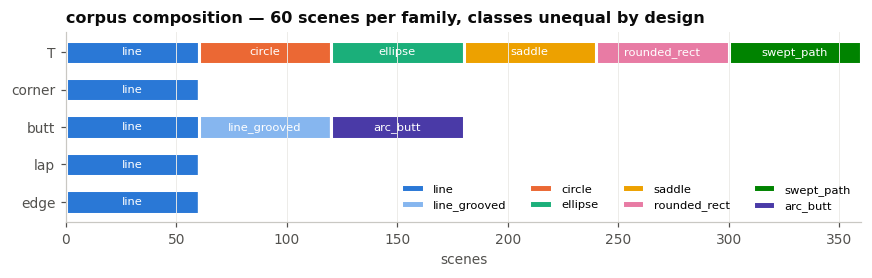

In [2]:
comp = FACTS.groupby(["joint_type", "family"], observed=True).agg(
    scenes=("scene_id", "size"), t_min=("t_min_mm", "min"), t_max=("t_min_mm", "max"),
    gap_med=("root_gap_mm", "median"), occl=("mean_occluded_fraction", "median"),
    angled=("angled", "mean")).reindex([tuple(s.split("/")) for s in ORDER_STRATA]).round(2)
print(comp.to_string())
print("\nsensor profiles:", FACTS.sensor_profile.value_counts().to_dict())
print("quality levels :", FACTS.quality_level.value_counts().to_dict())
print("T class by ISO 17659 term:", FACTS[FACTS.joint_type == "T"].iso_17659_term.value_counts().to_dict())

fig, ax = plt.subplots(figsize=(8, 2.6))
left = np.zeros(len(ORDER_JT))
fam_order = ["line", "line_grooved", "circle", "ellipse", "saddle", "rounded_rect", "swept_path", "arc_butt"]
fam_col = {"line": "#2a78d6", "line_grooved": "#86b6ef", "circle": "#eb6834", "ellipse": "#1baf7a",
           "saddle": "#eda100", "rounded_rect": "#e87ba4", "swept_path": "#008300", "arc_butt": "#4a3aa7"}
for fam in fam_order:
    vals = np.array([((FACTS.joint_type == jt) & (FACTS.family == fam)).sum() for jt in ORDER_JT])
    ax.barh(ORDER_JT, vals, left=left, color=fam_col[fam], edgecolor="white", linewidth=2, label=fam, height=0.62)
    for k, v in enumerate(vals):
        if v: ax.text(left[k] + v / 2, k, fam if v >= 60 else "", ha="center", va="center", fontsize=7.5, color="white")
    left += vals
ax.invert_yaxis(); ax.set_xlabel("scenes"); ax.set_title("corpus composition — 60 scenes per family, classes unequal by design", loc="left")
ax.legend(ncol=4, fontsize=7.5, loc="lower right"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 2. Task 1 — the coverage table

The headline question of the benchmark: *which mechanisms can express which joints?* Median
F1 per stratum × method under the perfect multi-view condition. Read the rows, not the
columns: a method's profile across families is its mechanism's signature.

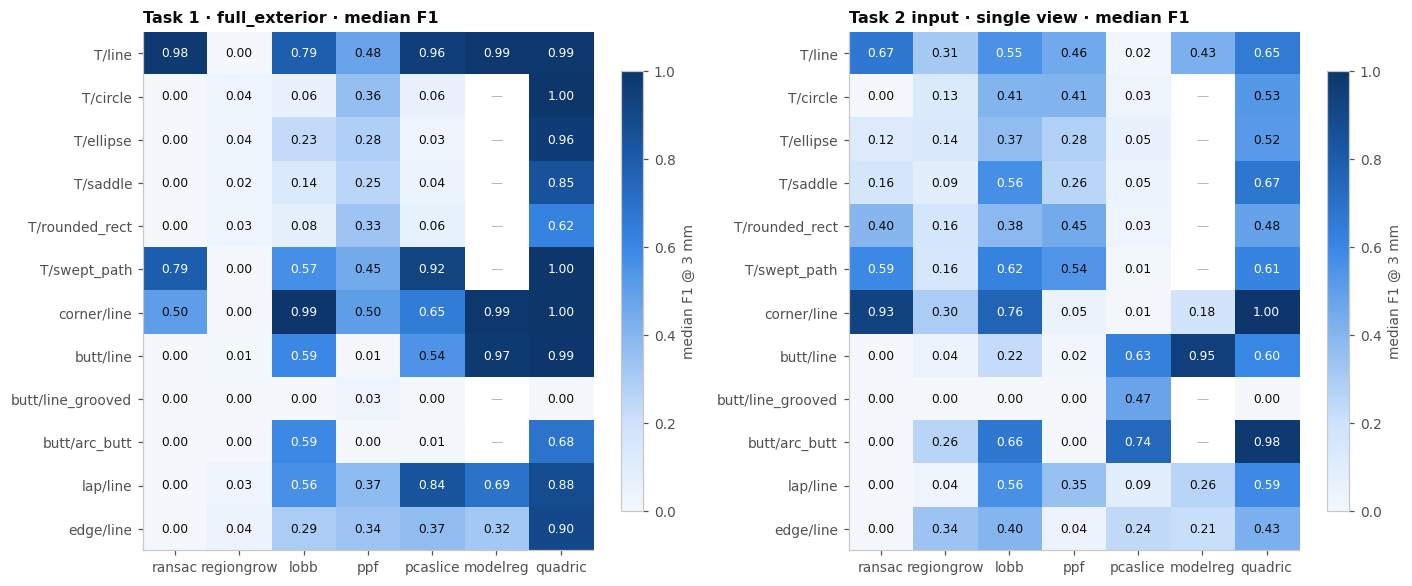

full_exterior
method             lit-ransac  lit-regiongrow  lit-lobb  lit-ppf  lit-pcaslice  lit-modelreg  lit-quadric
stratum                                                                                                  
T/line                   0.98            0.00      0.79     0.48          0.96          0.99         0.99
T/circle                 0.00            0.04      0.06     0.36          0.06           NaN         1.00
T/ellipse                0.00            0.04      0.23     0.28          0.03           NaN         0.96
T/saddle                 0.00            0.02      0.14     0.25          0.04           NaN         0.85
T/rounded_rect           0.00            0.03      0.08     0.33          0.06           NaN         0.62
T/swept_path             0.79            0.00      0.57     0.45          0.92           NaN         1.00
corner/line              0.50            0.00      0.99     0.50          0.65          0.99         1.00
butt/line                0.00   

In [3]:
cov = DF[DF.chunk.str.startswith("coverage")]
def cov_table(view, col="f1"):
    s = scene_level(cov[cov.condition == view], col)
    return s.pivot_table(index="stratum", columns="method", values=col, aggfunc="median").reindex(ORDER_STRATA)[METHODS]
T_full = cov_table("full_exterior"); T_single = cov_table("single")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
heat(T_full, "Task 1 · full_exterior · median F1", ax=axes[0])
heat(T_single, "Task 2 input · single view · median F1", ax=axes[1])
plt.tight_layout(); plt.show()
print("full_exterior"); print(T_full.round(2).to_string()); print("\nsingle"); print(T_single.round(2).to_string())

**Reading the table.**

* **The plane-intersection collapse is total and clean.** `lit-ransac` (plane RANSAC +
  pairwise intersection) holds 0,97 on straight T seams and **0,00 on every curved family
  and both curved-butt strata**. `lit-ppf` (point-pair features voting for plane pairs)
  degrades more gracefully on curved fillets (~0,25–0,36: a saddle or ring is locally a
  plane pair for short runs) and dies on butts. This is the answer to the plan's question
  *"where does the plane-intersection baseline stop working"*: at the first non-planar
  member, and there is no partial credit.
* **`lit-lobb` is the only method with a nonzero median on every stratum except grooved.**
  Its local-bounding-box flatness feature is a crease detector, which is exactly the
  invariant that survives curvature. Its full-view scores on closed rings (T/circle 0,06,
  rounded_rect 0,08) are *worse* than its single-view ones (0,41, 0,38): the full exterior
  cloud includes the far side of the tube and the bore crease, both real creases it
  faithfully reports — a precision failure of the mechanism, not a detection failure.
* **Grooved butts are a wall for five of six methods** (≈0,00 in full view). The groove
  walls put two long parallel creases either side of the root, and crease detectors
  return the wrong lines; the plane-pair methods find the bevel faces and intersect them
  above the joint. Only `lit-pcaslice`'s per-instance masks recover it (0,49 single-view).
  This finding stands on *decorrelated* geometry: the stratum was rebuilt with polygon
  outlines and re-run, and every number is unchanged from the rectangular version
  (`notes/dataset_plan.md`, step 3) — the groove is what defeats them, not the outline.
* **`lit-modelreg` posts 0,95–0,99 wherever it runs**, which is what a CAD-registration
  method should do when the CAD is the truth. It is the ceiling of the L0-with-CAD rung
  and a warning about how that rung is reported in the literature.
* **Straight plate seams are not solved either** — by the first six. Edge joints
  (0,29–0,37) and lap joints (crease at a thickness step, 0,37–0,84) remain hard for them
  on plain rectangles.
* **`lit-quadric` leads or ties every stratum but grooved** (notebook 11; added after the
  first run): 1,00 circle, 0,96 ellipse, 0,85 saddle at 0,01 mm RMSE — the quadric families
  are inside its surface model where they are outside everyone else's — and 0,99 butt,
  0,90 edge, 0,88 lap on the plates. Read its L1 row (§5) before crowning it: its L0
  stage, per-face surfaces with part membership, is the richest oracle in the ladder.

### 2.1 The straight-to-curved gap, per method

The same numbers as a dumbbell, holding the joint type fixed: each method's median F1 on
the straight T seam (`T/line`) against the mean of its medians over the five curved T
families. Same joint, same fillet, same L0 stage — only the seam's curvature changes, so
the length of the line is the price of the mechanism's planarity assumption and nothing
else. (`lit-modelreg` has no curved coverage by scope and is shown with its straight
point only.)

**Reading it.** Every mechanism loses most of its score to curvature — RANSAC 0,98 → 0,16,
the slicer 0,96 → 0,23, the crease detector 0,79 → 0,21 — with one exception worth
naming: `lit-ppf`'s line is the flattest (0,48 → 0,34). The point-pair voter decides
*locally*, and a ring or a saddle is a plane pair over any short run, so it keeps a third
of its score where the global plane fit keeps nothing; in full view it beats the crease
detector on four of the five curved T families (the crease detector is paying its
far-side-crease price there). In single view the ranking reverses (§2) — which is the
view a robot has.

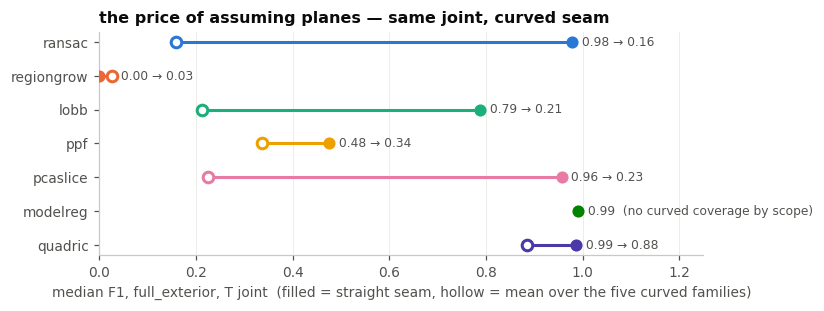

                T/line  curved T (mean of medians)
method                                            
lit-ransac        0.98                        0.16
lit-regiongrow    0.00                        0.03
lit-lobb          0.79                        0.21
lit-ppf           0.48                        0.34
lit-pcaslice      0.96                        0.23
lit-modelreg      0.99                         NaN
lit-quadric       0.99                        0.88


In [4]:
curvedT = ["T/circle", "T/ellipse", "T/saddle", "T/rounded_rect", "T/swept_path"]
straight = T_full.loc["T/line"]; curved = T_full.loc[curvedT].mean()
fig, ax = plt.subplots(figsize=(7.5, 2.9))
for i, m in enumerate(METHODS):
    a, b = straight[m], curved[m]
    ax.scatter([a], [i], color=COLOR[m], s=48, zorder=3)
    if np.isfinite(b):
        ax.plot([a, b], [i, i], color=COLOR[m], linewidth=2)
        ax.scatter([b], [i], facecolor="white", edgecolor=COLOR[m], s=48, zorder=3, linewidth=2)
        ax.text(max(a, b) + 0.02, i, f"{a:.2f} → {b:.2f}", va="center", fontsize=8, color=INK2)
    else:
        ax.text(a + 0.02, i, f"{a:.2f}  (no curved coverage by scope)", va="center", fontsize=8, color=INK2)
ax.set_yticks(range(len(METHODS))); ax.set_yticklabels([SHORT[m] for m in METHODS]); ax.invert_yaxis()
ax.set_xlim(0, 1.25); ax.set_xlabel("median F1, full_exterior, T joint  (filled = straight seam, hollow = mean over the five curved families)")
ax.set_title("the price of assuming planes — same joint, curved seam", loc="left"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print(pd.DataFrame({"T/line": straight, "curved T (mean of medians)": curved}).round(2).to_string())

## 3. Localization — the literature's own metric

F1 says whether a method found the seam; `rmse_med` says how well it placed it *when it
did*: the RMSE of a matched predicted path against its truth seam, resampled over
arclength (Yi et al. report max RMSE 0,64 mm / ME 1,16 mm on four workpieces against a
hand-taught path whose own error budget is ~0,5 mm, so a correct reimplementation against
constructed truth on a clean cloud should come in **below** 0,64 — matching it exactly
would be evidence of a bug). Cells are over matched seams only; a method that matches
nothing has no localization to report.

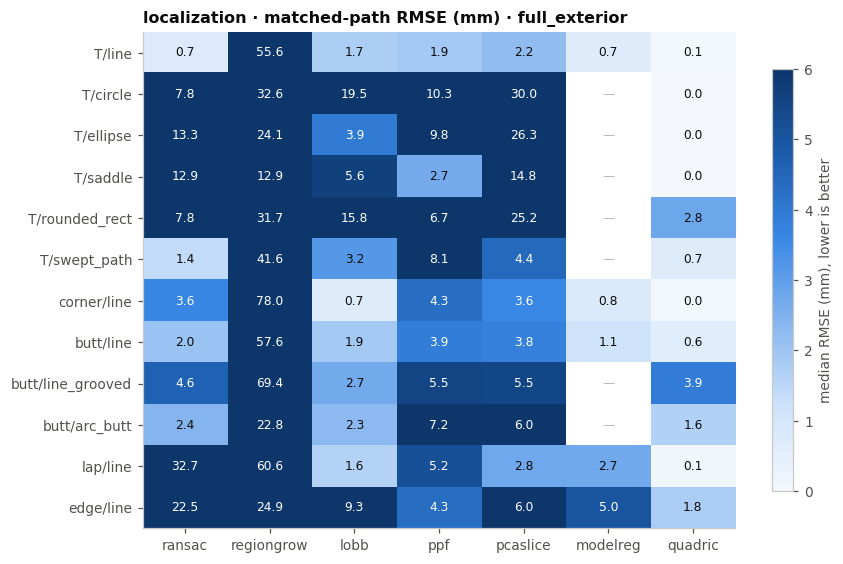

T/line median RMSE (mm): {'lit-lobb': 1.74, 'lit-modelreg': 0.66, 'lit-pcaslice': 2.21, 'lit-ppf': 1.88, 'lit-quadric': 0.07, 'lit-ransac': 0.75, 'lit-regiongrow': 55.63}


In [5]:
L = cov_table("full_exterior", "rmse_med")
fig, ax = plt.subplots(figsize=(8.2, 5.2))
heat(L, "localization · matched-path RMSE (mm) · full_exterior", cmap=SEQ, vmin=0, vmax=6, fmt="{:.1f}", ax=ax, cbar_label="median RMSE (mm), lower is better")
plt.tight_layout(); plt.show()
t_line = scene_level(cov[(cov.condition == "full_exterior")], "rmse_med")
t_line = t_line[t_line.stratum == "T/line"].groupby("method").rmse_med.median()
print("T/line median RMSE (mm):", t_line.round(2).to_dict())

**Reading it.** On the straight T seam the plane-intersection method sits in its paper's
regime — `lit-ransac` 0,75 mm median RMSE against constructed truth, next to the paper's
0,64 mm against a taught path with its own ~0,5 mm error budget; `lit-modelreg` 0,66 mm
is the registration residual. The crease detector is a coarser localizer: `lit-lobb`
places the straight T seam at 1,7 mm, and 1–2 mm elsewhere — the crease is a band of
points a few millimetres wide and its fitted curve sits inside that band, which is the
precision cost the F1 column already hinted at. `lit-ppf` 1,9 mm; `lit-pcaslice` 2,2 mm
(the per-slice centre of a masked strip); `lit-regiongrow` 56 mm — its "seam" is a
region boundary, and on a T the growing regions meet far from the crease. The RMSE table
therefore separates the mechanisms along a different axis from F1: the plane methods
fail by **not finding** curved seams and place the ones they find best; the crease
detector finds more and places it worse.

### 3.2 Which seam? — the D19 triple, and why the numbers are scored against `nominal`

With a root gap the two joint faces do not touch, so "the seam" is a **definition, not a
measurement** (`SCHEMA.md` §1.3). Three candidates exist and they are not the same curve:

| curve | definition | stored? |
|---|---|---|
| **`nominal`** | `Π_A ∩ Π_B` — the intersection of the two *extended* face planes, clipped to where both faces have support; the line the seam would occupy at zero gap | **yes — `seams[].sampled`, and every number in this notebook is scored against it** |
| `root` | the boundary edge of the *terminating* face — the deeper side of the gap (a T-fillet's standing-plate bottom edge) | derived array `_root` |
| `gap_mid` | midpoints of the closest-point pairs between the two faces | derived array `_gapmid` |

`nominal` is stored for three reasons, in order of weight: it is a property of the
*design*, so it does not move when the gap is resampled; it is symmetric under A↔B
relabelling (`root` is not — an asymmetric truth silently encodes part ordering); and it
is continuous as the gap goes to zero, where all three coincide. Another researcher may
prefer `root` (it is where a torch's wire actually lands) or `gap_mid` (it is what the
Phase 5 annotators clicked on butt joints — and they clicked `root` on T-joints). The
dataset does not force the choice: both alternatives ship as arrays, and re-scoring
against either is a one-line change in `ground_truth(curve=...)`. What it does force is
that the choice be *stated*, because the spread between them is O(gap): about one gap for
`root`, half for `gap_mid`, and — once the included angle is sampled (D18) — angle-dependent
(the ratio is 0,96 at acute fillets and 1,25 at obtuse ones), so no formula is published
and the offsets are read off per scene. Grooved butts carry `_grooveroot` instead (D36).

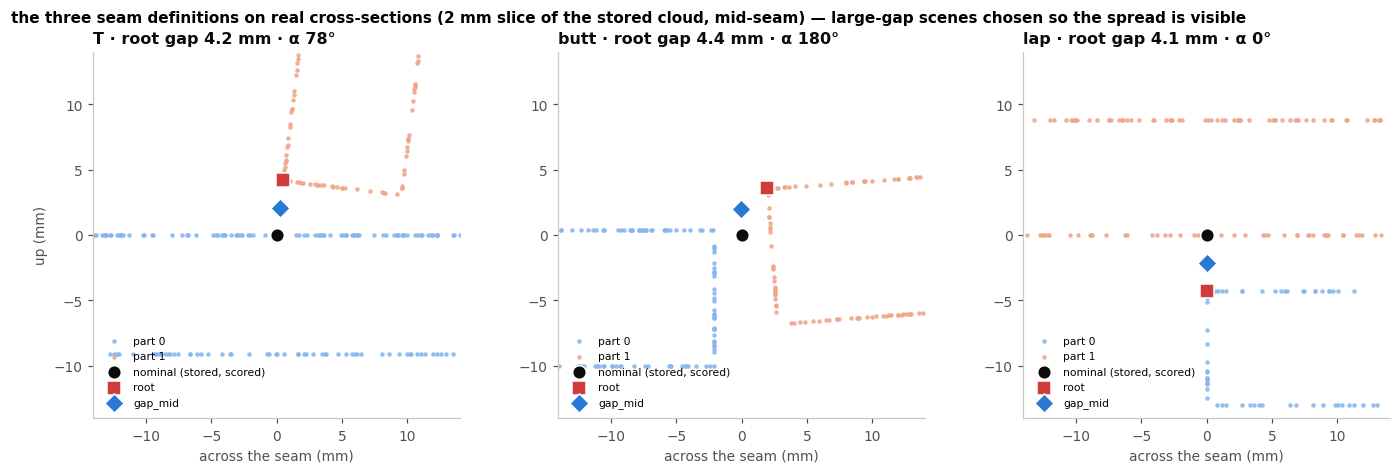

In [6]:
demos = [("T", "9a8eb697-0002000012"), ("butt", "80c0b152-0002000356"), ("lap", "539cd8ca-0002000096")]
OBJ = ["#86b6ef", "#f0a58a", "#9dbf8e"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (jt, sid) in zip(axes, demos):
    d = pathlib.Path(f"../out/bench_phase4/{jt}/{sid}")
    scene = json.loads((d / "scene.json").read_text()); z = np.load(d / "seams.npz"); c = np.load(d / "cloud.npz")
    sm = next(x for x in scene["seams"] if x["weldable"] and x["matches_joint_type"])
    k = sm["sampled"]["array"]; nom, root, gm = z[k], z[f"{k}_root"], z[f"{k}_gapmid"]
    i = len(nom) // 2; m = nom[i]; t = nom[-1] - nom[0]; t /= np.linalg.norm(t)
    e1 = np.cross([0, 0, 1.0], t); e1 /= np.linalg.norm(e1); e2 = np.cross(t, e1)        # the cross-section frame
    xyz, oid = c["xyz"], c["object_id"]
    sel = np.abs((xyz - m) @ t) < 1.0                                                     # a 2 mm slab across the seam
    P, o = xyz[sel], oid[sel]; win = 14.0
    near = (np.abs((P - m) @ e1) < win) & (np.abs((P - m) @ e2) < win)
    for k2, ob in enumerate(np.unique(o[near])):
        q = P[near][o[near] == ob]; ax.scatter((q - m) @ e1, (q - m) @ e2, s=4, color=OBJ[k2 % 3], alpha=0.8, label=f"part {ob}")
    for pt, name, col, mk in ((nom[i], "nominal (stored, scored)", INK, "o"), (root[i], "root", "#d03b3b", "s"), (gm[i], "gap_mid", "#2a78d6", "D")):
        ax.scatter([(pt - m) @ e1], [(pt - m) @ e2], s=80, color=col, marker=mk, zorder=5, edgecolor="white", linewidth=1, label=name)
    ax.set_aspect("equal"); ax.set_xlim(-win, win); ax.set_ylim(-win, win); ax.grid(False)
    ax.set_title(f"{jt} · root gap {scene['fit']['root_gap_mm']:.1f} mm · α {scene['joint']['included_angle_deg']:.0f}°", loc="left")
    ax.set_xlabel("across the seam (mm)"); ax.set_ylabel("up (mm)" if jt == "T" else "")
    ax.legend(fontsize=7, loc="lower left")
fig.suptitle("the three seam definitions on real cross-sections (2 mm slice of the stored cloud, mid-seam) — large-gap scenes chosen so the spread is visible", x=0.01, ha="left", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

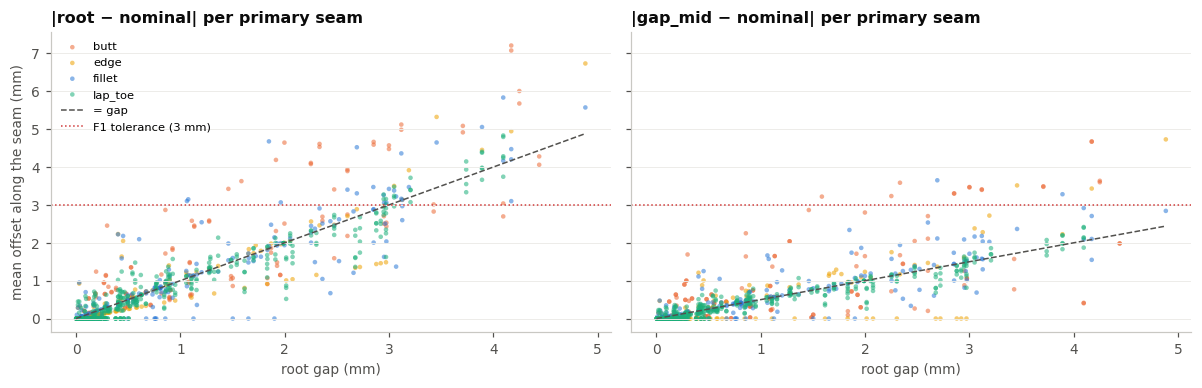

            seams  gap_med  root_med  root_max  gapmid_med  root_over_1mm  root_over_3mm
seam_class                                                                              
butt          117     1.10      1.24      7.21        0.63           0.58           0.23
edge          120     0.55      0.54      6.73        0.02           0.37           0.06
fillet        181     0.89      0.85      5.83        0.43           0.48           0.14
lap_toe       438     0.43      0.43      4.83        0.22           0.32           0.06

fillet root offset / gap, by included angle: {Interval(59, 80, closed='right'): 0.96, Interval(80, 100, closed='right'): 1.0, Interval(100, 121, closed='right'): 1.25}


In [7]:
# the conversion, corpus-wide: mean |root − nominal| and |gap_mid − nominal| per primary seam of the square-prep plate strata
rows = []
for _, r in FACTS[FACTS.seam_family.isna() & (FACTS.prep == "square")].iterrows():
    d = pathlib.Path(f"../out/bench_phase4/{r.joint_type}/{r.scene_id}")
    scene = json.loads((d / "scene.json").read_text()); z = np.load(d / "seams.npz")
    for sm in scene["seams"]:
        if not (sm["weldable"] and sm["matches_joint_type"]): continue
        k = sm["sampled"]["array"]
        if f"{k}_root" not in z.files: continue
        nom, root, gm = z[k], z[f"{k}_root"], z[f"{k}_gapmid"]
        rows.append(dict(joint_type=r.joint_type, seam_class=sm["seam_class"], gap=scene["fit"]["root_gap_mm"],
                         angle=scene["joint"]["included_angle_deg"],
                         off_root=float(np.linalg.norm(root - nom, axis=1).mean()), off_gm=float(np.linalg.norm(gm - nom, axis=1).mean())))
D19 = pd.DataFrame(rows)
CLS_COL = {"fillet": "#2a78d6", "butt": "#eb6834", "lap_toe": "#1baf7a", "edge": "#eda100"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, col, lab in zip(axes, ("off_root", "off_gm"), ("|root − nominal|", "|gap_mid − nominal|")):
    for cls, g in D19.groupby("seam_class"):
        ax.scatter(g.gap, g[col], s=9, color=CLS_COL[cls], alpha=0.55, label=cls, edgecolor="none")
    gg = np.linspace(0, D19.gap.max(), 50)
    ax.plot(gg, gg if col == "off_root" else gg / 2, color=INK2, linewidth=1, linestyle="--", label="= gap" if col == "off_root" else "= gap / 2")
    ax.axhline(3.0, color="#d03b3b", linewidth=1, linestyle=":", label="F1 tolerance (3 mm)")
    ax.set_xlabel("root gap (mm)"); ax.set_title(lab + " per primary seam", loc="left"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("mean offset along the seam (mm)"); axes[0].legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()
tbl = D19.groupby("seam_class").agg(seams=("gap", "size"), gap_med=("gap", "median"), root_med=("off_root", "median"), root_max=("off_root", "max"),
                                    gapmid_med=("off_gm", "median"), root_over_1mm=("off_root", lambda x: (x > 1).mean()), root_over_3mm=("off_root", lambda x: (x > 3).mean())).round(2)
print(tbl.to_string())
fil = D19[D19.seam_class == "fillet"]
print("\nfillet root offset / gap, by included angle:", fil.assign(b=pd.cut(fil.angle, [59, 80, 100, 121])).groupby("b", observed=True).apply(lambda x: (x.off_root / x.gap).median()).round(2).to_dict())

**What the choice costs, in the numbers above.** A method that returns the *root* line
on a scene with a 1 mm gap is charged ~1 mm of lateral error against `nominal` — inside
the 3 mm F1 tolerance, so the coverage table is insensitive to the choice, but visible
in the RMSE column at the 0,6–1 mm level. And it is not a corner case: the root offset exceeds
the 3 mm tolerance for **23% of butt centrelines, 14% of fillets and 6% of lap/edge
seams** (median root offset ≈ one gap, maximum 7 mm), and on those seams the choice of
curve flips a match. Two consequences for the paper: (1) state the curve in every table
caption (this notebook: `nominal`, always); (2) when comparing to a published number,
convert — the literature's hand-taught paths are `root`-like on fillets and
`gap_mid`-like on butts, which is exactly what the Phase 5 annotators reproduced. The
figure above is the visual to put next to that sentence.

## 4. Repeatability — what a seed is worth

`lit-ransac` is the one randomised method. The box plots the advisor asked for: per scene,
the spread of F1 over 30 RANSAC seeds, grouped by joint type. The deterministic five are
included as a *measurement*: their max spread over the verify seeds must be exactly zero.

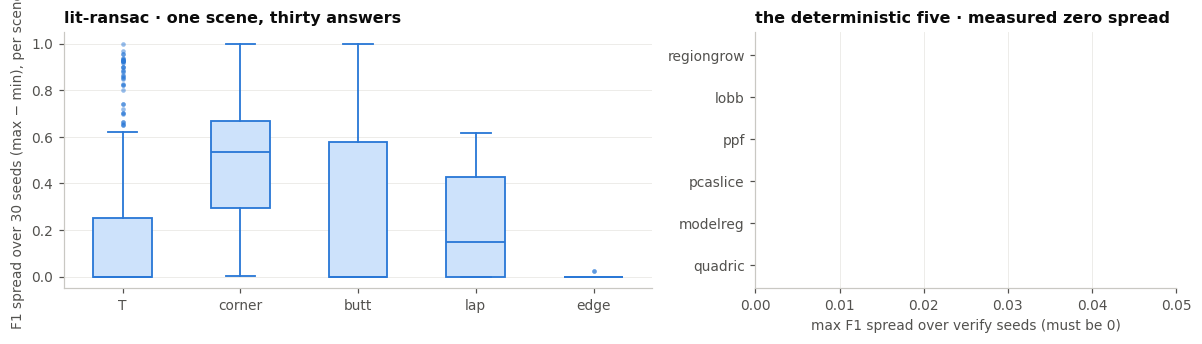

lit-ransac: fraction of scenes with spread > 0,25: {'T': 0.25, 'butt': 0.42, 'corner': 0.82, 'edge': 0.0, 'lap': 0.45}
deterministic max spread: {'lit-regiongrow': 0.0, 'lit-lobb': 0.0, 'lit-ppf': 0.0, 'lit-pcaslice': 0.0, 'lit-modelreg': 0.0, 'lit-quadric': 0.0}


In [8]:
r = cov[(cov.condition == "full_exterior") & (cov.method == "lit-ransac")]
sp = r.groupby(["joint_type", "scene_id"]).f1.agg(["min", "median", "max"]); sp["spread"] = sp["max"] - sp["min"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
data = [sp.loc[jt, "spread"].values for jt in ORDER_JT]
bp = ax.boxplot(data, labels=ORDER_JT, widths=0.5, patch_artist=True, showfliers=True,
                flierprops=dict(marker="o", markersize=3, markerfacecolor=COLOR["lit-ransac"], markeredgecolor="none", alpha=0.5))
for b in bp["boxes"]: b.set(facecolor="#cde2fb", edgecolor=COLOR["lit-ransac"], linewidth=1.2)
for k in ("whiskers", "caps", "medians"):
    for l in bp[k]: l.set(color=COLOR["lit-ransac"], linewidth=1.2)
ax.set_ylabel("F1 spread over 30 seeds (max − min), per scene"); ax.set_title("lit-ransac · one scene, thirty answers", loc="left"); ax.grid(axis="x", visible=False)
ax = axes[1]
det = cov[(cov.condition == "full_exterior") & (cov.method != "lit-ransac")]
mx = det.groupby(["method", "scene_id"]).f1.agg(lambda x: x.max() - x.min()).groupby("method").max().reindex([m for m in METHODS if m != "lit-ransac"])
ax.barh([SHORT[m] for m in mx.index], mx.values, color=[COLOR[m] for m in mx.index], height=0.55)
ax.set_xlim(0, 0.05); ax.set_xlabel("max F1 spread over verify seeds (must be 0)"); ax.set_title("the deterministic five · measured zero spread", loc="left"); ax.grid(axis="y", visible=False); ax.invert_yaxis()
plt.tight_layout(); plt.show()
print("lit-ransac: fraction of scenes with spread > 0,25:", (sp.spread > 0.25).groupby(level="joint_type").mean().round(2).to_dict())
print("deterministic max spread:", mx.round(4).to_dict())

**Reading it.** A single-draw number for `lit-ransac` is not a measurement: on a sizeable
share of scenes the same cloud gives F1 anywhere from failure to success depending on
the RANSAC seed alone. Every `lit-ransac` cell in this notebook is therefore a median
over seeds *per scene*, and the paper's box plot should be this figure. The five
deterministic methods show exactly zero spread — a property the generator can measure
and the field does not report.

## 5. The oracle ladder — what each paper's unpublished stage is worth

Each method's L0 run receives its own coarse stage (a segmentation network in the
original paper) as an oracle from truth; L1 withholds it and changes nothing else. The
delta is the price of the stage the paper did not release. `lit-ppf` additionally has an
exact-normals rung (the generator's analytic normals in place of estimated ones), and
`lit-modelreg` has its two published arms (`dense` target features; `global` init outside
the roughly-positioned envelope).

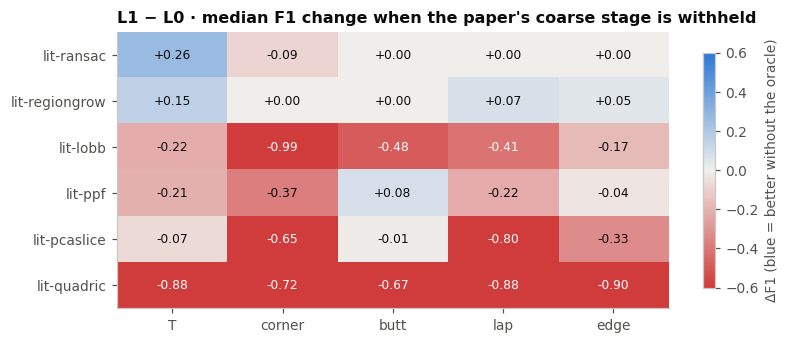

L0 / L1 medians by joint type:
                  L0                             L1                         
joint_type         T  butt corner  edge   lap     T  butt corner  edge   lap
method                                                                      
lit-lobb        0.25  0.50   0.99  0.29  0.56  0.03  0.02   0.00  0.12  0.15
lit-pcaslice    0.07  0.01   0.65  0.37  0.84  0.00  0.00   0.00  0.04  0.03
lit-ppf         0.33  0.00   0.50  0.34  0.37  0.12  0.08   0.13  0.30  0.15
lit-quadric     0.91  0.67   1.00  0.90  0.88  0.03  0.00   0.28  0.00  0.00
lit-ransac      0.00  0.00   0.50  0.00  0.00  0.26  0.00   0.42  0.00  0.00
lit-regiongrow  0.03  0.00   0.00  0.04  0.03  0.18  0.00   0.00  0.09  0.11

lit-ppf exact-normals rung (ΔF1 vs estimated normals): {'T': 0.03, 'corner': 0.1, 'butt': 0.5, 'lap': 0.05, 'edge': 0.41}



lit-quadric AS PUBLISHED (quadric_distance_full_exterior) vs chain, median F1 per stratum:
                   distance  chain
stratum                           
T/line                 0.99   0.99
T/circle               0.41   1.00
T/ellipse              0.42   0.96
T/saddle               0.44   0.85
T/rounded_rect         0.24   0.62
T/swept_path           1.00   1.00
corner/line            1.00   1.00
butt/line              0.99   0.99
butt/line_grooved      0.00   0.00
butt/arc_butt          0.66   0.68
lap/line               0.88   0.88
edge/line              0.89   0.90

lit-quadric AS PUBLISHED (quadric_distance_single) vs chain, median F1 per stratum:
                   distance  chain
stratum                           
T/line                 0.65   0.65
T/circle               0.48   0.53
T/ellipse              0.52   0.52
T/saddle               0.67   0.67
T/rounded_rect         0.46   0.48
T/swept_path           0.61   0.61
corner/line            1.00   1.00
butt/line         

In [9]:
l0 = scene_level(cov[cov.condition == "full_exterior"], "f1").rename(columns={"f1": "L0"})
l1 = scene_level(DF[DF.chunk.str.startswith("l1_")], "f1").rename(columns={"f1": "L1"})
lad = l0.merge(l1, on=["method", "stratum", "joint_type", "scene_id"])
tbl = lad.groupby(["method", "joint_type"])[["L0", "L1"]].median().unstack("joint_type")
d = (tbl["L1"] - tbl["L0"])[ORDER_JT].reindex([m for m in METHODS if m != "lit-modelreg"])
fig, ax = plt.subplots(figsize=(7.5, 3.2))
heat(d, "L1 − L0 · median F1 change when the paper's coarse stage is withheld", cmap=DIV, vmin=-0.6, vmax=0.6, fmt="{:+.2f}", ax=ax, cbar_label="ΔF1 (blue = better without the oracle)")
plt.tight_layout(); plt.show()
print("L0 / L1 medians by joint type:"); print(tbl.round(2).to_string())
ppf_ex = scene_level(DF[DF.chunk == "ppf_exact_normals_full_exterior"], "f1").groupby("joint_type").f1.median()
ppf_l0 = l0[l0.method == "lit-ppf"].groupby("joint_type").L0.median()
print("\nlit-ppf exact-normals rung (ΔF1 vs estimated normals):", (ppf_ex - ppf_l0).reindex(ORDER_JT).round(2).to_dict())
mr = {c: scene_level(DF[DF.chunk == c], "f1").groupby("joint_type").f1.median().reindex(ORDER_JT).round(2).to_dict()
      for c in ("modelreg_dense_features", "modelreg_global_init")}
for c in ("quadric_distance_full_exterior", "quadric_distance_single"):
    if (DF.chunk == c).any():
        q = scene_level(DF[DF.chunk == c], "f1").groupby("stratum").f1.median().reindex(ORDER_STRATA)
        q0 = scene_level(cov[(cov.method == "lit-quadric") & (cov.condition == c.split("_", 2)[2])], "f1").groupby("stratum").f1.median().reindex(ORDER_STRATA)
        print(f"\nlit-quadric AS PUBLISHED ({c}) vs chain, median F1 per stratum:"); print(pd.DataFrame({"distance": q, "chain": q0}).round(2).to_string())
print("lit-modelreg L0 (oracle features, near init):", l0[l0.method == "lit-modelreg"].groupby("joint_type").L0.median().reindex(ORDER_JT).round(2).to_dict())
for k, v in mr.items(): print(f"lit-modelreg {k}:", v)

**Reading it.** The steepest drop belongs to the new leader: **`lit-quadric` goes from a
pooled 0,93 to 0,00 without its surfaces** — only the thick curved members survive
(rounded_rect 0,53, swept_path 0,72), where region growing on a tube wall is easy; on thin
plates the grown regions merge through the thickness, and a wrong surface partition yields
wrong pairs and no seams. The mechanism is exact given the welding surfaces, and finding the
welding surfaces is the entire problem. The same story holds, at lower altitude, for the
crease detector: **`lit-lobb` goes from 0,43 to 0,03 without its masks** — the K-Net segmentation in the original paper is what confines
the crease detector to the parts, and without it every crease in the scene (plate edges,
the bore, the outline corners) is a seam. That matters for how the paper frames any
improvement: a modification that helps lobb at L0 must be checked at L1, or it may be
inheriting the oracle's work. `lit-ransac` and `lit-regiongrow` move slightly *up* at
L1 on some classes: their L0 band excludes the fixture and off-class regions but also
constrains them to a 40 mm corridor, and on the classes where they fail anyway the
corridor was the more binding constraint. `lit-ppf`'s exact-normals rung prices normal
estimation on its own, and the price is the whole of its coplanar failure: with the
generator's analytic normals its butt F1 rises by 0,50 and edge by 0,41 — the mechanism
is sound, the estimated normals on a thin coplanar pair are not. `lit-modelreg`'s
`dense` arm (raw surfaces as target features) is where its registration slides along the
seam — butt 0,97 → 0,11 — and the `global` arm (init outside the roughly-positioned
envelope) is where near-symmetric assemblies register onto their mirror image (butt 0,78,
lap 0,57).

## 6. Sensor noise — the axis the literature evaluates without

`noise_scale` multiplies the derived stereo σ_z (0 = clean, 1 = the stored profile,
2 = twice it), realised on the single view — noise on a cloud no sensor returns would be
a condition without an interpretation. Small multiples per sensor profile (`d435i`,
`stereo_good`, `stereo_poor` differ in baseline/focal/subpixel), one line per method,
the winner in colour.

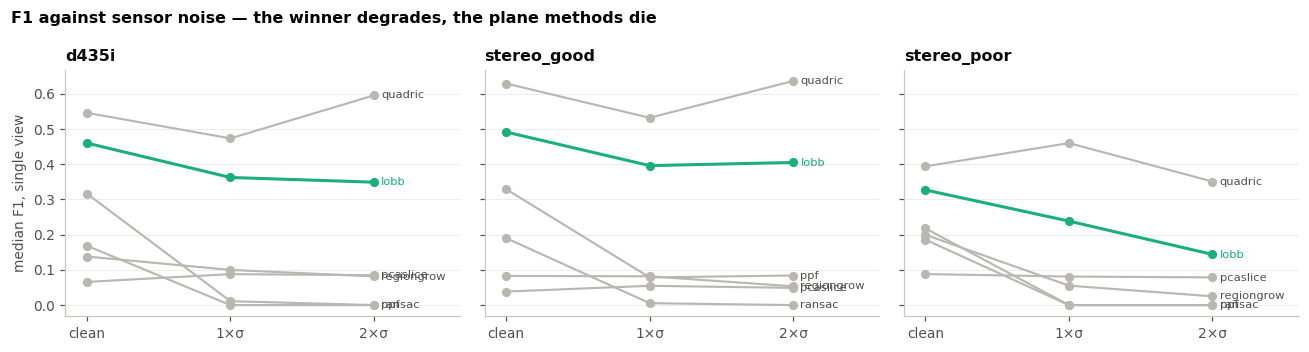

ns               0.0   1.0   2.0
method                          
lit-lobb        0.44  0.34  0.31
lit-pcaslice    0.06  0.07  0.07
lit-ppf         0.30  0.02  0.00
lit-quadric     0.56  0.49  0.57
lit-ransac      0.18  0.00  0.00
lit-regiongrow  0.13  0.08  0.05


In [10]:
n0 = cov[cov.condition == "single"].assign(ns=0.0)
nn = DF[DF.chunk.str.startswith("noise")].assign(ns=lambda d: d.noise_scale)
N = pd.concat([n0, nn]); N = N[N.method != "lit-modelreg"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, prof in zip(axes, ["d435i", "stereo_good", "stereo_poor"]):
    sub = N[N.sensor_profile == prof]
    g = sub.groupby(["method", "ns", "scene_id"]).f1.median().groupby(["method", "ns"]).median().unstack("ns")
    for m in METHODS:
        if m not in g.index: continue
        emph = m == "lit-lobb"
        ax.plot(g.columns, g.loc[m], marker="o", markersize=5, linewidth=2 if emph else 1.4,
                color=COLOR[m] if emph else GRAY, zorder=3 if emph else 2, label=SHORT[m])
        ax.text(g.columns[-1] + 0.05, g.loc[m].iloc[-1], SHORT[m], fontsize=7.5, va="center", color=COLOR[m] if emph else INK2)
    ax.set_title(prof, loc="left"); ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["clean", "1×σ", "2×σ"]); ax.set_xlim(-0.15, 2.6); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("median F1, single view")
fig.suptitle("F1 against sensor noise — the winner degrades, the plane methods die", x=0.01, ha="left", fontsize=10.5, fontweight="bold")
plt.tight_layout(); plt.show()
g = N.groupby(["method", "ns", "scene_id"]).f1.median().groupby(["method", "ns"]).median().unstack("ns")
print(g.round(2).to_string())

**Reading it.** `lit-quadric` is essentially noise-immune (0,56 → 0,49 → 0,57): a
least-squares surface fit over thousands of points averages the sensor noise out, and the
intersection inherits the averaged surfaces. Among the point-local methods `lit-lobb` is
the most robust (0,44 → 0,34 → 0,31 pooled over profiles; gentlest on `stereo_good` — 0,49 → 0,40 → 0,40 — and steepest on `stereo_poor`,
0,33 → 0,24 → 0,14, where the derived σ_z at these standoffs is millimetres). The plane
methods go to zero at the stored profile: RANSAC's inlier threshold and PPF's normal estimation are both tuned for
CAD-clean clouds, and the derived σ_z of a real stereo sensor at these standoffs is
already outside their operating window. This is a table the literature could not produce
— its clouds are either CAD or a single physical sensor — and it is the argument for the
sensor axis being a first-class benchmark dimension (D16).

## 7. Task 2 — the Most Probable Seam

Single view, one answer: which seam is the one a coarse-positioned torch is at? The label
is `mps_rule-0.1` — argmax of *visible* arclength over weldable seams, ties broken by
fold — a **geometric proxy**, a convention over exact geometry (confirmed by the advisor
as the intended scope; it does not claim to identify the load-bearing seam, which no
single view can). Selection: did the MPS seam receive a prediction at all (one-to-one
matching over the weldable truth set)? Localization: the matched pair's path error. On
closed rings every reported metric is distance-based and rotation-invariant, and the one
endpoint quantity is NaN by rule (D39).

Two methods sit at 100% selection for a reason that is not skill: `lit-pcaslice` receives
one mask *per seam instance* and `lit-modelreg` transfers every seam from the model, so
both trivially cover the MPS — read their localization, not their match rate.

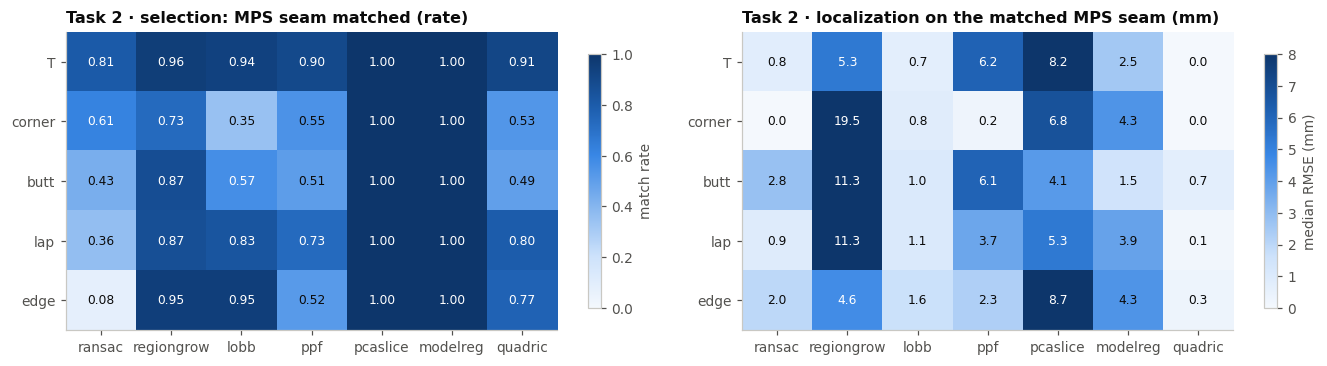

selection rate:
joint_type         T  corner  butt   lap  edge
method                                        
lit-ransac      0.81    0.61  0.43  0.36  0.08
lit-regiongrow  0.96    0.73  0.87  0.87  0.95
lit-lobb        0.94    0.35  0.57  0.83  0.95
lit-ppf         0.90    0.55  0.51  0.73  0.52
lit-pcaslice    1.00    1.00  1.00  1.00  1.00
lit-modelreg    1.00    1.00  1.00  1.00  1.00
lit-quadric     0.91    0.53  0.49  0.80  0.77

localization RMSE (mm) on matched:
joint_type        T  corner  butt   lap  edge
method                                       
lit-ransac      0.8     0.0   2.8   0.9   2.0
lit-regiongrow  5.3    19.5  11.3  11.3   4.6
lit-lobb        0.7     0.8   1.0   1.1   1.6
lit-ppf         6.2     0.2   6.1   3.7   2.3
lit-pcaslice    8.2     6.8   4.1   5.3   8.7
lit-modelreg    2.5     4.3   1.5   3.9   4.3
lit-quadric     0.0     0.0   0.7   0.1   0.3

closed-ring rows with a finite end_error (must be 0): 0


In [11]:
t2 = DF[DF.chunk.str.startswith("task2")].copy()
t2["mps_matched"] = t2.mps_matched.astype(str).str.lower() == "true"
t2["mps_null"] = t2.mps_null.astype(str).str.lower() == "true"
t2 = t2[~t2.mps_null]
sel = t2.groupby(["method", "joint_type", "scene_id"]).mps_matched.mean().groupby(["method", "joint_type"]).mean().unstack("joint_type")[ORDER_JT].reindex(METHODS)
loc = t2[t2.mps_matched].groupby(["method", "joint_type", "scene_id"]).rmse.median().groupby(["method", "joint_type"]).median().unstack("joint_type")[ORDER_JT].reindex(METHODS)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))
heat(sel.T, "Task 2 · selection: MPS seam matched (rate)", ax=axes[0], cbar_label="match rate")
heat(loc.T, "Task 2 · localization on the matched MPS seam (mm)", cmap=SEQ, vmin=0, vmax=8, fmt="{:.1f}", ax=axes[1], cbar_label="median RMSE (mm)")
plt.tight_layout(); plt.show()
print("selection rate:"); print(sel.round(2).to_string()); print("\nlocalization RMSE (mm) on matched:"); print(loc.round(1).to_string())
print("\nclosed-ring rows with a finite end_error (must be 0):", int(np.isfinite(t2[t2.mps_closed.astype(str).str.lower() == "true"].end_error_mm).sum()))

### 7.1 The MPS margin — how much of a choice the single view leaves

`mps_margin` is the runner-up's visible arclength over the winner's: 0 means only one seam
is visible at all (the degenerate regime, where MPS reduces to "the seam you can see"),
values inside (0, 1) mean the argmax is a genuine choice. The distribution is a property of
the class geometry, not of any method — and three classes are structurally pinned:
**T → 0** (complementary fillet lobes: one visible at a time), **corner → ~1** (the inside
fillet and the outside corner are the same physical line), **saddle → 0** (a single
weldable seam once the bore is confined). The `approach_cone` camera regime (6c(b))
raises the graded share on the classes where geometry permits; this corpus was generated
under `uniform_sphere`, so what is shown is the unassisted distribution. The figure shows
the pinning directly: `T/line`, `T/saddle` and `butt/arc_butt` sit at exactly 0 (one
visible seam), `corner/line` and both straight butt strata at ~1 (two seams of equal
visible length — the corner's inside and outside lines, the butt's two coplanar
centrelines), and only the closed rings (circle, ellipse, rounded rectangle) and the
edge/lap strata spread across (0, 1).

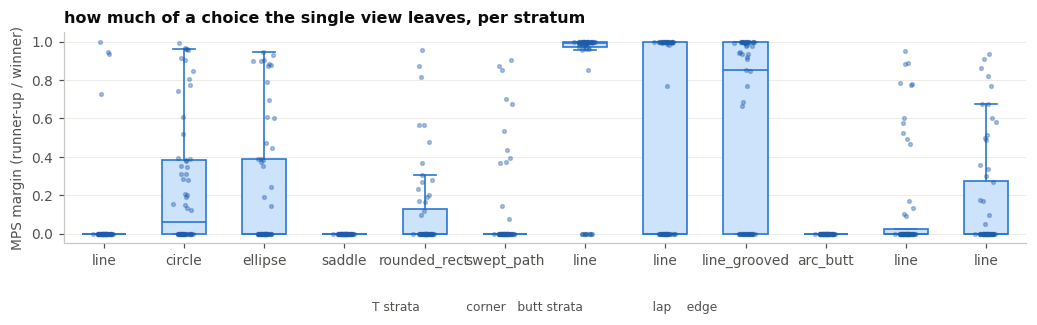

share of scenes with a graded margin (0 < m < 1):
stratum
T/line               0.05
T/circle             0.50
T/ellipse            0.37
T/saddle             0.00
T/rounded_rect       0.28
T/swept_path         0.20
corner/line          0.80
butt/line            0.40
butt/line_grooved    0.53
butt/arc_butt        0.00
lap/line             0.25
edge/line            0.33

MPS class by joint type (which seam class the rule names):
mps_class   butt  edge  fillet  lap_toe
joint_type                             
T              0     0     360        0
corner         0    21      39        0
butt         160     0       0       20
lap            0     0       0       60
edge           0    33       0       27


In [12]:
mm = t2.drop_duplicates("scene_id")[["scene_id", "stratum", "joint_type", "mps_margin", "mps_class"]]
fig, ax = plt.subplots(figsize=(9.5, 3.2))
xs = [mm[mm.stratum == s].mps_margin.dropna().values for s in ORDER_STRATA]
bp = ax.boxplot(xs, labels=[s.split("/")[1] if s.count("/") else s for s in ORDER_STRATA], widths=0.55, patch_artist=True, showfliers=False)
for b, s in zip(bp["boxes"], ORDER_STRATA): b.set(facecolor="#cde2fb", edgecolor="#2a78d6", linewidth=1.1)
for k in ("whiskers", "caps", "medians"):
    for l in bp[k]: l.set(color="#2a78d6", linewidth=1.1)
for i, s in enumerate(ORDER_STRATA):
    v = mm[mm.stratum == s].mps_margin.dropna().values
    ax.scatter(np.random.default_rng(0).normal(i + 1, 0.06, len(v)), v, s=6, color="#1c5cab", alpha=0.35, zorder=3)
ax.set_ylabel("MPS margin (runner-up / winner)"); ax.set_title("how much of a choice the single view leaves, per stratum", loc="left"); ax.grid(axis="x", visible=False)
ax.text(0.5, -0.32, "T strata            corner   butt strata                  lap    edge", transform=ax.transAxes, ha="center", fontsize=8, color=INK2)
plt.tight_layout(); plt.show()
print("share of scenes with a graded margin (0 < m < 1):")
print(mm.groupby("stratum").mps_margin.apply(lambda x: ((x > 0) & (x < 1)).mean()).reindex(ORDER_STRATA).round(2).to_string())
print("\nMPS class by joint type (which seam class the rule names):")
print(pd.crosstab(mm.joint_type, mm.mps_class).reindex(ORDER_JT).to_string())

**Reading it.** `lit-quadric` localizes the MPS seam at 0,0–0,7 mm on every class — an
order of magnitude under everyone else — while its selection is mid-pack (0,49 butt to
0,91 T): it finds the seam it finds exactly, and misses the rest outright. `lit-lobb`
leads selection among the methods that actually search (0,79 overall, 0,94 on T) with the
best localization after the quadric (0,7–1,6 mm on every class);
`lit-ransac` is the precision specialist — exact where its planes exist, matched barely
half the time; `lit-regiongrow`'s high match rate dissolves into 5–20 mm localization
(it finds *something* near the MPS, not the seam). **Corner is the selection trap**
(lobb 0,35): the rule breaks the inside-fillet/outside-corner tie by fold, which no
detector knows. The MPS crosstab is a result in itself: butt names an off-class `lap_toe`
(the thickness step) in 20 of 180 scenes — D25's "weldable, not primary" doing real work.

## 8. The fixture — D12, paired twins

The same 40 scenes (8 per joint type, straight plate strata) generated twice, once with
the workpieces resting on a fixture plate, matched on `twin_key` (bit-identical workpiece
geometry and seam truth). Paired ΔF1 per method; the plan's prediction was phantom
plane-pair candidates from `lit-ransac`/`lit-ppf` along every part-fixture contact.

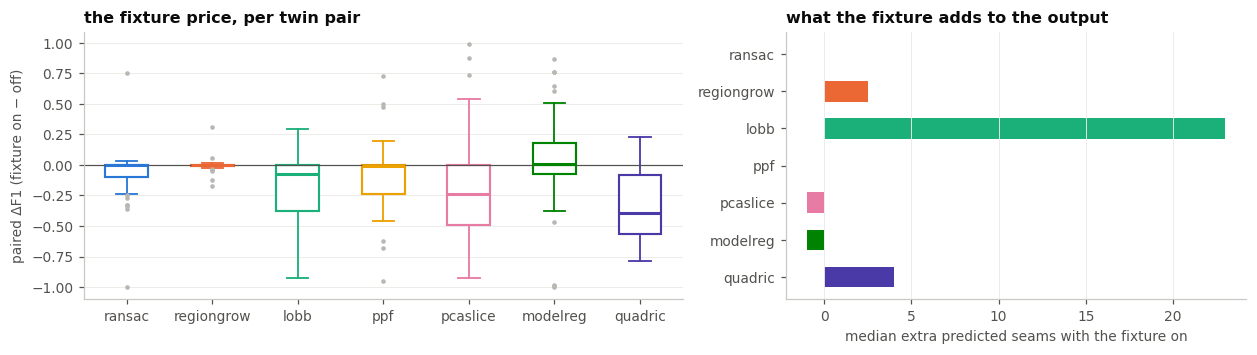

                pairs  dF1_med  dPrec_med  extra_seams
method                                                
lit-ransac         40     0.00       0.00          0.0
lit-regiongrow     40     0.00       0.00          2.5
lit-lobb           40    -0.07      -0.22         23.0
lit-ppf            40    -0.01      -0.01          0.0
lit-pcaslice       40    -0.24      -0.24         -1.0
lit-modelreg       40     0.01       0.00         -1.0
lit-quadric        40    -0.39      -0.51          4.0

median ΔF1 by joint type:
method      lit-ransac  lit-regiongrow  lit-lobb  lit-ppf  lit-pcaslice  lit-modelreg  lit-quadric
joint_type                                                                                        
T                -0.09            0.00     -0.30    -0.00         -0.01          0.01        -0.36
corner           -0.17            0.00     -0.49    -0.16         -0.08          0.00        -0.41
butt              0.00            0.00     -0.03     0.00         -0.36          0

In [13]:
fx = DF[DF.chunk.str.startswith("fixture")].copy()
# fixture-arm scenes are not in facts.csv: twin keys from the twin corpus index
tk = {}
for jt in ORDER_JT:
    for ln in pathlib.Path(f"../out/bench_phase4_fx/{jt}/index.jsonl").read_text().splitlines():
        r = json.loads(ln)
        if r.get("emitted"): tk[r["scene_id"]] = r["twin_key"]
fx["twin_key"] = fx.twin_key.fillna(fx.scene_id.map(tk))
fx["joint_type"] = fx.joint_type.fillna(fx.scene_id.map(lambda s: None))
g = fx.groupby(["method", "fixture", "twin_key"]).agg(f1=("f1", "median"), prec=("precision", "median"), n=("n_pred_seams", "median")).reset_index()
p = g.pivot_table(index=["method", "twin_key"], columns="fixture", values=["f1", "prec", "n"])
d = pd.DataFrame({"dF1": p[("f1", True)] - p[("f1", False)], "dPrec": p[("prec", True)] - p[("prec", False)], "dN": p[("n", True)] - p[("n", False)]}).dropna().reset_index()
jt_of = fx.drop_duplicates("twin_key").set_index("twin_key").joint_type
d["joint_type"] = d.twin_key.map(jt_of)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.3), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
xs = [d[d.method == m].dF1.values for m in METHODS]
bp = ax.boxplot(xs, labels=[SHORT[m] for m in METHODS], widths=0.5, patch_artist=True, showfliers=True,
                flierprops=dict(marker="o", markersize=3, markerfacecolor=GRAY, markeredgecolor="none"))
for b, m in zip(bp["boxes"], METHODS): b.set(facecolor="white", edgecolor=COLOR[m], linewidth=1.4)
for k in ("whiskers", "caps"):
    for l, m in zip(bp[k], [m for m in METHODS for _ in (0, 1)]): l.set(color=COLOR[m], linewidth=1.2)
for l, m in zip(bp["medians"], METHODS): l.set(color=COLOR[m], linewidth=2)
ax.axhline(0, color=INK2, linewidth=0.8); ax.set_ylabel("paired ΔF1 (fixture on − off)"); ax.set_title("the fixture price, per twin pair", loc="left"); ax.grid(axis="x", visible=False)
ax = axes[1]
dn = d.groupby("method").dN.median().reindex(METHODS)
ax.barh([SHORT[m] for m in METHODS], dn.values, color=[COLOR[m] for m in METHODS], height=0.55); ax.invert_yaxis()
ax.set_xlabel("median extra predicted seams with the fixture on"); ax.set_title("what the fixture adds to the output", loc="left"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print(d.groupby("method").agg(pairs=("dF1", "size"), dF1_med=("dF1", "median"), dPrec_med=("dPrec", "median"), extra_seams=("dN", "median")).reindex(METHODS).round(2).to_string())
print("\nmedian ΔF1 by joint type:"); print(d.pivot_table(index="joint_type", columns="method", values="dF1", aggfunc="median").reindex(ORDER_JT)[METHODS].round(2).to_string())

**Reading it.** The prediction was wrong in direction, and the measurement says why: the
plane methods' L0 band oracle excludes the fixture region, so they never see the contact
(Δ ≈ 0). The price lands on the crease detector — **`lit-lobb` returns a median 23 extra
seams with the fixture on** (precision −0,22; ΔF1 −0,30 on T and −0,49 on corner, the
classes where the plate rests on the table) — and on the slicer (`lit-pcaslice` −0,24:
fixture points inside its per-instance band drag the slice centres). `lit-modelreg` and
`lit-regiongrow` are unmoved. And the **largest price of all seven is `lit-quadric`'s, ΔF1
−0,39**: its L0 part membership counts the fixture as a part, so every plate-face ×
fixture-face pair with a contact band becomes a "seam" along the table — the paper's
two-part world has no fixture, and the mechanism has no notion that a seam lies between
*workpieces* (D13, the rule the generator applies to its own candidates). The 274-of-360
twin yield is itself a D12 result: the
fixture arm loses seeds by occluding the last visible seam (corner worst at 36/60) and
butt loses 13 to a contact under the root closing the joint.

## 9. Covariates — what the winner is sensitive to

The nine "first results" plots the plan asked for, condensed to the ones that carry a
finding for the winner and the plane baseline: thickness, root gap, sampling density,
camera elevation and occlusion (single view), and the ISO 17659 T-joint / angle-joint
split. Binned medians over scenes; straight strata only, so the family effect is not
confounded with the covariate.

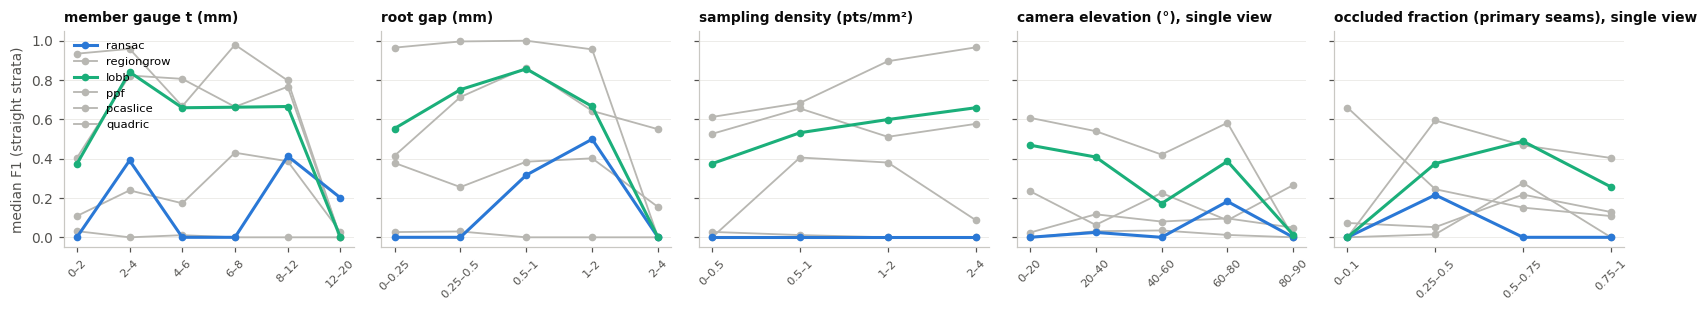

T/line: T-joint vs angle joint (ISO 17659), median F1 full_exterior
angled          T-joint (3.10)  angle joint (3.12)
method                                            
lit-ransac                0.99                0.93
lit-regiongrow            0.00                0.00
lit-lobb                  0.81                0.79
lit-ppf                   0.63                0.03
lit-pcaslice              0.97                0.95
lit-modelreg              0.99                0.99
lit-quadric               0.99                0.97

T curved families: T-joint vs angle joint
angled          T-joint (3.10)  angle joint (3.12)
method                                            
lit-ransac                0.00                0.00
lit-regiongrow            0.03                0.04
lit-lobb                  0.11                0.17
lit-ppf                   0.37                0.27
lit-pcaslice              0.08                0.03
lit-modelreg               NaN                 NaN
lit-quadric           

In [14]:
s = scene_level(cov[cov.condition == "full_exterior"], "f1").merge(FACTS[["scene_id", "t_min_mm", "root_gap_mm", "density_per_mm2"]], on="scene_id")
s = s[s.stratum.isin(STRAIGHT)]
ss = scene_level(cov[cov.condition == "single"], "f1").merge(FACTS[["scene_id", "elevation_deg", "mean_occluded_fraction"]], on="scene_id")
ss = ss[ss.stratum.isin(STRAIGHT)]
panels = [(s, "t_min_mm", "member gauge t (mm)", [0, 2, 4, 6, 8, 12, 20]), (s, "root_gap_mm", "root gap (mm)", [0, 0.25, 0.5, 1, 2, 4]),
          (s, "density_per_mm2", "sampling density (pts/mm²)", [0, 0.5, 1, 2, 4, 8]), (ss, "elevation_deg", "camera elevation (°), single view", [0, 20, 40, 60, 80, 90]),
          (ss, "mean_occluded_fraction", "occluded fraction (primary seams), single view", [0, 0.1, 0.25, 0.5, 0.75, 1.0])]
fig, axes = plt.subplots(1, 5, figsize=(15, 2.9), sharey=True)
for ax, (dd, col, lab, bins) in zip(axes, panels):
    dd = dd.copy(); dd["bin"] = pd.cut(dd[col], bins=bins)
    for m in METHODS:
        if m == "lit-modelreg": continue
        g = dd[dd.method == m].groupby("bin", observed=True).f1.median()
        emph = m in ("lit-lobb", "lit-ransac")
        ax.plot(range(len(g)), g.values, marker="o", markersize=4, linewidth=2 if emph else 1.2, color=COLOR[m] if emph else GRAY, label=SHORT[m], zorder=3 if emph else 2)
    ax.set_xticks(range(len(g))); ax.set_xticklabels([f"{iv.left:g}–{iv.right:g}" for iv in g.index], rotation=45, fontsize=7.5)
    ax.set_title(lab, loc="left", fontsize=9); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("median F1 (straight strata)"); axes[0].legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

ang = scene_level(cov[(cov.condition == "full_exterior") & (cov.joint_type == "T")], "f1").merge(FACTS[["scene_id", "angled", "family"]], on="scene_id")
tbl = ang[ang.family == "line"].groupby(["method", "angled"]).f1.median().unstack("angled").rename(columns={False: "T-joint (3.10)", True: "angle joint (3.12)"}).reindex(METHODS)
print("T/line: T-joint vs angle joint (ISO 17659), median F1 full_exterior"); print(tbl.round(2).to_string())
angc = ang[ang.family != "line"].groupby(["method", "angled"]).f1.median().unstack("angled").rename(columns={False: "T-joint (3.10)", True: "angle joint (3.12)"}).reindex(METHODS)
print("\nT curved families: T-joint vs angle joint"); print(angc.round(2).to_string())

**Reading it — with the confound named first.** Over the straight strata the covariate
bins are not independent of the stratum: the thinnest bin (t < 2 mm) is the edge-joint
stratum, the thickest (12–20 mm) and the largest root gaps (2–4 mm, the ISO 9692-1 row
gaps) are the grooved butts, and the lowest occlusion bin is lap/edge. So the two
collapses of the winner at the extremes of the gauge and gap panels are the edge and
grooved strata reappearing, not a thickness effect — the paper's version of these plots
must be per stratum. What survives the confound: **sampling density is a clean monotone
gain for the crease detector** (0,38 → 0,67 from < 0,5 to 2–4 pts/mm²) and irrelevant to
the plane methods; **camera elevation has the expected sweet spot** — the crease detector
is best at grazing views (0,49 at 0–20°) and near zero looking straight down (80–90°),
where the crease flattens into the image plane; and the plane-intersection method is
near zero on straight strata in *every* bin because its zeros on butt/lap/edge dominate
the pooled straight set (its T/line 0,98 is in §2).

The ISO 17659 split is worth a row of its own in the paper: an **angle joint is not a
harder T-joint for the crease detector** (`lit-lobb` 0,81 → 0,79) or for the model
registration, and barely for RANSAC (0,99 → 0,93) — but **`lit-ppf` falls from 0,63 to
0,03**: its corner-detection heuristics assume the 90° dihedral, and the standard's own
taxonomy is what exposes it.

## 10. Cost

Median seconds per *run* per method (`sec` measures the method call only — not oracle
preparation, not scoring). Two readings: single-view clouds are 3–5× cheaper than full
exterior for every method, and withholding the oracle costs the crease detector 10× (3,5 s
against 0,35 s: it must examine every point instead of the masked parts). Note what this
column does **not** explain: the L1 `lit-ransac` chunk dominated the batch wall-clock
(13,7 h against 2,3 h for its oracle sibling) while its method time barely moved — the
cost was in *scoring* the hundreds of phantom polylines an unmasked RANSAC returns
(one-to-one matching is quadratic in candidates), which is itself a statement about
what that method emits without its stage.

In [15]:
cost = DF[DF.chunk.str.startswith(("coverage", "l1_"))].groupby(["method", "arm", "condition"]).sec.median().unstack(["arm", "condition"]).reindex(METHODS).round(2)
print(cost.to_string())

arm                       L0                   L1
condition      full_exterior single full_exterior
method                                           
lit-ransac              0.02   0.01          0.08
lit-regiongrow          0.36   0.06          1.14
lit-lobb                0.35   0.10          3.48
lit-ppf                 0.13   0.05          0.81
lit-pcaslice            0.24   0.11          0.28
lit-modelreg            1.99   1.70           NaN
lit-quadric             0.60   0.19          1.39


## 11. Discussion

**What the benchmark says, in one sentence.** Seam extraction as the field practises it
cannot express half the joint taxonomy: every plane-intersection method (the dominant
mechanism in the literature and in this project's own robot) scores zero on every
curved family, and the one mechanism that survives curvature — the crease detector —
pays for it with precision, on closed rings, near fixtures, and above all without the
segmentation masks its paper did not release.

**Two winners, and the question between them.** With the seventh method the table has
two leaders that fail in opposite ways. `lit-quadric` is exact wherever its welding
surfaces are given — 0,93 pooled F1, 0,01 mm on rings and saddles, immune to sensor noise —
and collapses to 0,00 the moment they are not; its failures are all *segmentation*
failures (thin plates merging through the thickness, the fixture read as a part). `lit-lobb`
never needs to know what a surface is and survives every condition at half the accuracy;
its failures are all *precision* failures. So the improvement with the highest ceiling is
no longer a two-body prior for the crease detector: it is **a welding-surface segmentation
good enough to feed the quadric intersection** — everything downstream of it is already
exact — evaluated at L1, on the fixture twins, and on thin plates, which is where every
unsupervised partition measured here breaks. The crease detector's route remains the
fallback that needs no segmentation at all. Before the seventh method, `lit-lobb` was the method to improve:
the only nonzero profile across strata, the best Task-2 selection and localization, the
most noise-robust. Its failures are all *precision* failures of the same kind — real
creases that are not seams: (1) the far side and bore creases of closed rings in full
view (0,06 vs 0,41 single-view on T/circle); (2) the corner class in Task 2 (0,35), where
the inside fillet and outside corner are one physical line and the rule's fold tie-break is
unknown to it; (3) fixture-contact lines (+23 phantom seams, corner ΔF1 −0,49). All three
share a physical prior the detector lacks — *a weld seam lies between two workpieces* —
which makes a single modification (crease acceptance conditioned on two-body membership,
rather than on flatness alone) the natural candidate for the project's own contribution,
to be evaluated at L1 as well as L0.

**What the corpus contributed that the literature could not.** The straight-to-curved
dumbbell (§2.1) exists only because the curved families were constructed with exact truth;
the noise table (§6) exists only because the sensor is a model with named profiles; the
repeatability box plot (§4) exists only because the truth is fixed while the seed varies;
the fixture pairs (§8) exist only because a twin has bit-identical geometry. None of these
is a stronger claim about any method than the method's own paper makes — they are the
*conditions* those papers did not vary.

**Threats to validity, stated.** (a) Every method is a reimplementation; `lit-lobb`'s
was reviewed with its first author (oracle masks, Mean-Shift off, LOBB radius endorsed),
the others are faithful to their papers as read, with the two contradictions found in
`lit-ransac`'s equations documented. (b) L0 oracles are derived from truth, so L0 is an
upper bound on what a real coarse stage would give — the ladder is the honest framing.
(c) `lit-modelreg`'s scope is slab/prism plates; its absence on curved strata is a
scope limit, not a failure. (d) The corpus is synthetic, tier 1: no sensor artefacts
beyond the analytic stereo model; Phase 8 renders and the Phase 9 real subset are the
next two rungs of that ladder. (e) The MPS label is a geometric proxy by decision, and
this notebook never claims otherwise.

**The paper's tables, in order.** §2 (coverage, both views, seven methods) · §2.1 (the gap) · §3
(localization) · §4 (repeatability) · §5 (the ladder) · §6 (noise × profile) · §7 (Task 2,
plus the margin distribution per class) · §8 (fixture) · §9 (covariates and the
ISO 17659 split) · §10 (cost). The batch csv is the single source for all of them.